In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int

In [4]:
envconfig = EnvConfig()

In [6]:
env = RideShareEnv(config=envconfig)

In [7]:
env.graph

In [11]:
G = env.graph

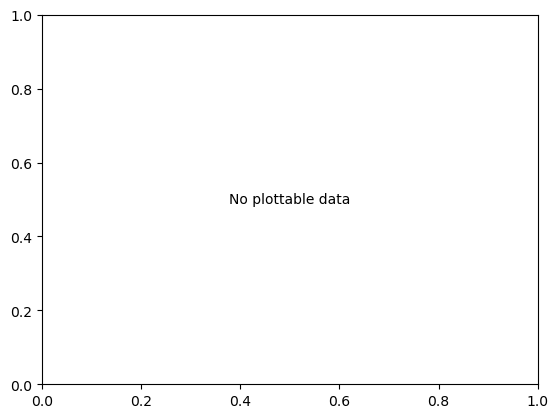

In [ ]:
plot_edge_or_node_attr(env.graph, "lambda")

In [20]:
G_proj = ox.project_graph(G)

xs = np.array([d["x"] for _, d in G_proj.nodes(data=True)])
ys = np.array([d["y"] for _, d in G_proj.nodes(data=True)])

x0 = xs.mean()
y0 = ys.mean()

for n, d in G_proj.nodes(data=True):
    d["x_centered"] = float(d["x"] - x0)
    d["y_centered"] = float(d["y"] - y0)

In [21]:
xs_c = xs - x0
ys_c = ys - y0
max_abs = max(np.abs(xs_c).max(), np.abs(ys_c).max())  # largest radius

for n, d in G_proj.nodes(data=True):
    d["x_norm"] = float((d["x"] - x0) / max_abs)
    d["y_norm"] = float((d["y"] - y0) / max_abs)

In [22]:
inspect_graph(G_proj)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=42448329- attributes: {'y': np.float64(4512488.562702919), 'x': np.float64(587807.9521535904), 'highway': 'traffic_signals', 'street_count': np.int64(4), 'num_chargers': 'False', 'lambda': '0.03396187824979478', 'x_centered': 1672.1193518387154, 'y_centered': 451.96970820985734, 'x_norm': 0.23349252278384477, 'y_norm': 0.0631124490460277}

Sample edge attributes: {'osmid': 1271523176, 'highway': 'secondary', 'maxspeed': 64.74938089, 'name': 'Central Park West', 'oneway': False, 'reversed': False, 'length': 738.3714754358834, 'geometry': <LINESTRING (586414.381 4514420.955, 586455.005 4514496.537, 586493.999 4514...>, 'lanes': "(('5', '4'), '4')", 'unit': 'kph', 'travel_time_min': '1.101129370453801'}
